# Seoul Bikes Framework Models
### Evan André Santana Pacheco A01769493
### TC3009C.601

Predictive Modeling of Urban Bike-Sharing Demand in Seoul
Seoul Bike Sharing Demand (UCI Machine Learning Repository)
https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

Licence
Creative Commons Attribution 4.0 International (CC BY 4.0)

Three models fitted with frameworks: an OLS regression that verifies the manual
implementation and reports the statistical significance of every coefficient,
a decision tree, and a random forest. All share the training subset produced by
the ETL, so any difference in their results comes from the model and not the data.

Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Prepared data to train.

In [34]:
from google.colab import drive

drive.mount("/content/gdrive")
%cd "/content/gdrive/MyDrive/IAconcentrada/seoul"
!ls

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/MyDrive/IAconcentrada/seoul
 fig_81_tree_depth.png	     ols_summary.txt	 X_val_seoul.csv
 fig_82_tree_structure.png   SeoulBikeData.csv	 Y_test_seoul.csv
'first version backup'	     X_test_seoul.csv	 Y_train_seoul.csv
 map_seoulData.csv	     X_train_seoul.csv	 Y_val_seoul.csv


Load the subsets. Unlike the by-hand implementation the features stay in their
original units. OLS solves in closed form and does not need scaling, and trees
split on thresholds, so scaling would not change their decisions.

In [35]:
X_train = pd.read_csv('X_train_seoul.csv')
Y_train = pd.read_csv('Y_train_seoul.csv').values.flatten()

X_val = pd.read_csv('X_val_seoul.csv')
Y_val = pd.read_csv('Y_val_seoul.csv').values.flatten()

X_test = pd.read_csv('X_test_seoul.csv')
Y_test = pd.read_csv('Y_test_seoul.csv').values.flatten()

print(f"train: {len(X_train)} rows, val: {len(X_val)} rows, test: {len(X_test)} rows")
print("Features:", list(X_train.columns))

train: 7896 rows, val: 384 rows, test: 480 rows
Features: ['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Weekend']


Metrics MSE, RMSE, MAE and R2.

In [36]:
def metrics(y_true, y_pred):
	return {"MSE": mean_squared_error(y_true, y_pred),
			"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
			"MAE": mean_absolute_error(y_true, y_pred),
			"R2": r2_score(y_true, y_pred)}

results = []
def record(name, subset, y_true, y_pred):
	results.append({"Model": name, "Subset": subset, **metrics(y_true, y_pred)})

Baseline prediction based on the mean of the demand of the training subset.

In [37]:
mean_train = Y_train.mean()

record("Baseline (mean)", "val",  Y_val,  np.full(len(Y_val), mean_train))
record("Baseline (mean)", "test", Y_test, np.full(len(Y_test), mean_train))

print("Baseline RMSE test:", np.sqrt(mean_squared_error(Y_test, np.full(len(Y_test), mean_train))))

Baseline RMSE test: 628.2146468965021


The OLS gives back the basic statistics to rate the performance of the linear regression.

In [38]:
X_train_sm = sm.add_constant(X_train)
X_val_sm   = sm.add_constant(X_val,  has_constant='add')
X_test_sm  = sm.add_constant(X_test, has_constant='add')

ols = sm.OLS(Y_train, X_train_sm).fit()
print(ols.summary())
with open('ols_summary.txt', 'w', encoding='utf-8') as f:
    f.write(str(ols.summary()))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     795.9
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:35:56   Log-Likelihood:                -59164.
No. Observations:                7896   AIC:                         1.184e+05
Df Residuals:                    7883   BIC:                         1.184e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

As a side note on the coefficients: all features are significant at the 5% level except the Dew point temperature, with p value of 0.20, its confidence interval crosses zero and its contribution cannot be distinguished from no contribution at all. This is consistent with the correlation matrix, where Dew point and Temperature correlate at 0.92: with two variables carrying nearly the same information, the model cannot attribute the effect reliably to either one. The summary also reports a condition number above 1000, which statsmodels flags as evidence of multicollinearity.

Coefficient table with statistical significance and latex output.

In [39]:
coef_table = pd.DataFrame({
	"Coefficient": ols.params,
	"Std. Error": ols.bse,
	"t": ols.tvalues,
	"P>|t|": ols.pvalues,
	"CI 2.5%": ols.conf_int()[0],
	"CI 97.5%": ols.conf_int()[1],
}).round(4)

display(coef_table)
print("\nNot significant (p >= 0.05):", list(coef_table[coef_table["P>|t|"] >= 0.05].index))
print(coef_table.to_latex(escape=True, float_format="%.4f"))

,Coefficient,Std. Error,t,P>|t|,CI 2.5%,CI 97.5%
const,491.5820,108.2777,4.5400,0.0000,279.3291,703.8350
Hour,29.0794,0.7715,37.6910,0.0000,27.5670,30.5918
Temperature(°C),20.3562,4.2290,4.8134,0.0000,12.0662,28.6463
Humidity(%),-10.4886,1.2023,-8.7237,0.0000,-12.8454,-8.1317
Wind speed (m/s),20.8444,5.3595,3.8892,0.0001,10.3384,31.3504
Visibility (10m),-45.0531,21.1270,-2.1325,0.0330,-86.4676,-3.6386
Dew point temperature(°C),5.7263,4.4738,1.2800,0.2006,-3.0435,14.4962
Solar Radiation (MJ/m2),-85.6291,8.0648,-10.6176,0.0000,-101.4382,-69.8199
Rainfall(mm),-59.2789,4.8928,-12.1156,0.0000,-68.8701,-49.6878
Snowfall (cm),28.8874,14.5496,1.9854,0.0471,0.3663,57.4084



Not significant (p >= 0.05): ['Dew point temperature(°C)']
\begin{tabular}{lrrrrrr}
\toprule
 & Coefficient & Std. Error & t & P>|t| & CI 2.5\% & CI 97.5\% \\
\midrule
const & 491.5820 & 108.2777 & 4.5400 & 0.0000 & 279.3291 & 703.8350 \\
Hour & 29.0794 & 0.7715 & 37.6910 & 0.0000 & 27.5670 & 30.5918 \\
Temperature(°C) & 20.3562 & 4.2290 & 4.8134 & 0.0000 & 12.0662 & 28.6463 \\
Humidity(\%) & -10.4886 & 1.2023 & -8.7237 & 0.0000 & -12.8454 & -8.1317 \\
Wind speed (m/s) & 20.8444 & 5.3595 & 3.8892 & 0.0001 & 10.3384 & 31.3504 \\
Visibility (10m) & -45.0531 & 21.1270 & -2.1325 & 0.0330 & -86.4676 & -3.6386 \\
Dew point temperature(°C) & 5.7263 & 4.4738 & 1.2800 & 0.2006 & -3.0435 & 14.4962 \\
Solar Radiation (MJ/m2) & -85.6291 & 8.0648 & -10.6176 & 0.0000 & -101.4382 & -69.8199 \\
Rainfall(mm) & -59.2789 & 4.8928 & -12.1156 & 0.0000 & -68.8701 & -49.6878 \\
Snowfall (cm) & 28.8874 & 14.5496 & 1.9854 & 0.0471 & 0.3663 & 57.4084 \\
Seasons & 128.2638 & 6.0664 & 21.1432 & 0.0000 & 116.3720

Predictions and metrics of the OLS model on validation and test.

In [40]:
record("Linear Regression (OLS)", "val",  Y_val,  ols.predict(X_val_sm))
record("Linear Regression (OLS)", "test", Y_test, ols.predict(X_test_sm))
ols_test = ols.predict(X_test_sm)
print(metrics(Y_test, ols_test))

{'MSE': 234724.37761597117, 'RMSE': 484.4836195538206, 'MAE': 369.47152553336394, 'R2': 0.4046179522745339}


Model 2: Decision Tree

The splitting criteria is squared_error, which selects the threshold that most
reduces the variance of the target inside the resulting child nodes.
As a side note the entropy and gini are impurity measures for classification and do not apply to regression.
max_depth is selected on the validation subset; the test subset is reserved for
the final evaluation.

Best max_depth by validation: 10


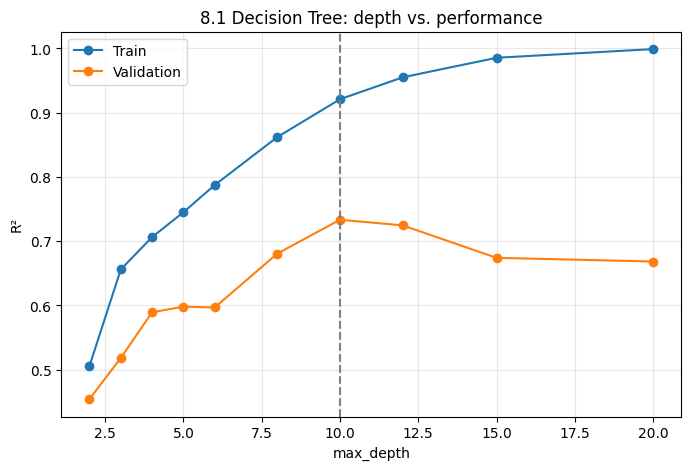

In [41]:
depths = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
r2_tr, r2_v = [], []

for d in depths:
	t = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train, Y_train)
	r2_tr.append(r2_score(Y_train, t.predict(X_train)))
	r2_v.append(r2_score(Y_val, t.predict(X_val)))

best_depth = depths[int(np.argmax(r2_v))]
print("Best max_depth by validation:", best_depth)

plt.figure(figsize=(8,5))
plt.plot(depths, r2_tr, marker='o', label='Train')
plt.plot(depths, r2_v, marker='o', label='Validation')
plt.axvline(best_depth, color='gray', linestyle='--')
plt.xlabel("max_depth"); plt.ylabel("R²")
plt.title("8.1 Decision Tree: depth vs. performance")
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig('fig_81_tree_depth.png', dpi=150, bbox_inches='tight')
plt.show()

Final tree fitted with the depth selected above and its metrics on validation and test.

In [42]:
tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42).fit(X_train, Y_train)

record("Decision Tree", "val",  Y_val,  tree.predict(X_val))
record("Decision Tree", "test", Y_test, tree.predict(X_test))
print(metrics(Y_test, tree.predict(X_test)))

{'MSE': 67713.959613205, 'RMSE': 260.2190608183901, 'MAE': 166.28738449825198, 'R2': 0.82824248446802}


Structure of the tree considering only the first levels are drawn, since the full tree at the selected depth has hundreds of leaves it is unreadable on a page. The hour appears repeatedly along a single path, progressively narrowing the window until it isolates a specific hour. This is how a tree represents the two daily labor peaks that a single linear coefficient could not.

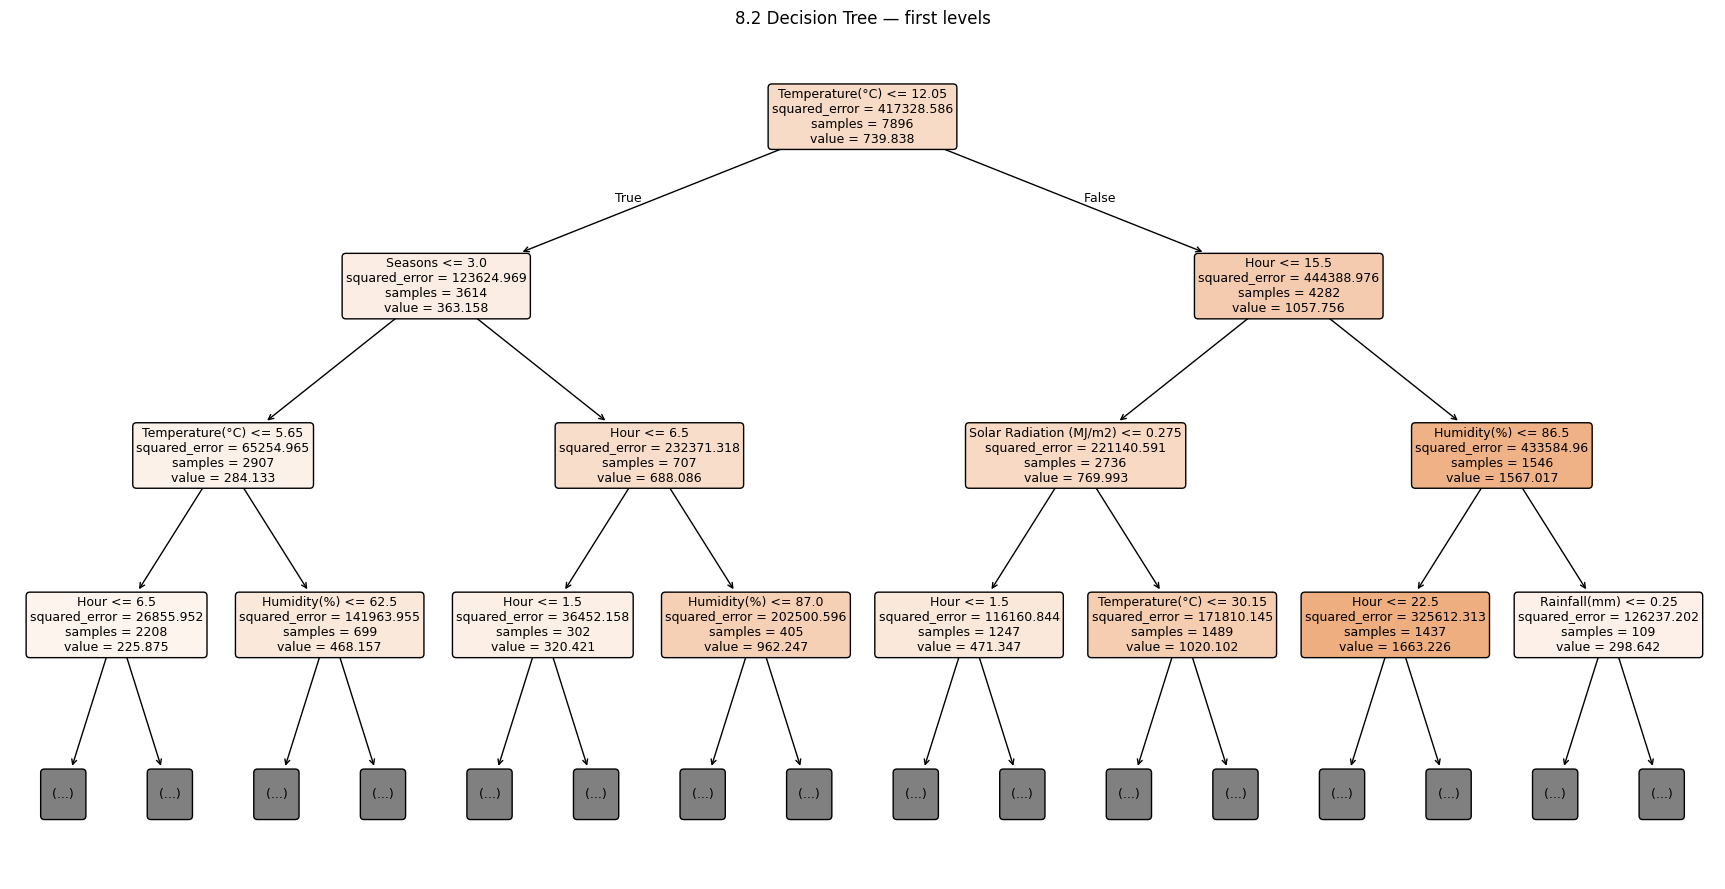

|--- Temperature(°C) <= 12.05
|   |--- Seasons <= 3.00
|   |   |--- Temperature(°C) <= 5.65
|   |   |   |--- truncated branch of depth 8
|   |   |--- Temperature(°C) >  5.65
|   |   |   |--- truncated branch of depth 8
|   |--- Seasons >  3.00
|   |   |--- Hour <= 6.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- Hour >  6.50
|   |   |   |--- truncated branch of depth 8
|--- Temperature(°C) >  12.05
|   |--- Hour <= 15.50
|   |   |--- Solar Radiation (MJ/m2) <= 0.28
|   |   |   |--- truncated branch of depth 8
|   |   |--- Solar Radiation (MJ/m2) >  0.28
|   |   |   |--- truncated branch of depth 8
|   |--- Hour >  15.50
|   |   |--- Humidity(%) <= 86.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- Humidity(%) >  86.50
|   |   |   |--- truncated branch of depth 8



In [43]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(22,11))
plot_tree(tree, max_depth=3, feature_names=list(X_train.columns),
          filled=True, rounded=True, fontsize=9)
plt.title("8.2 Decision Tree — first levels")
plt.savefig('fig_82_tree_structure.png', dpi=110, bbox_inches='tight')
plt.show()

print(export_text(tree, feature_names=list(X_train.columns), max_depth=2))

Model 3: Random Forest

An ensemble of trees, each fitted on a bootstrap sample of the training rows and
considering a random subset of features at every split. Averaging their predictions
reduces the variance that makes a single deep tree overfit, which is why depth is
left unrestricted here while the single tree needed a limit.

In [44]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, Y_train)
rf_test = rf.predict(X_test)

record("Random Forest", "val",  Y_val,  rf.predict(X_val))
record("Random Forest", "test", Y_test, rf_test)
print(metrics(Y_test, rf_test))
print("Random Forest train:", metrics(Y_train, rf.predict(X_train)))

{'MSE': 41250.105376875, 'RMSE': 203.1012195356665, 'MAE': 133.24254166666665, 'R2': 0.89536846382289}
Random Forest train: {'MSE': 4572.75916409891, 'RMSE': 67.62217952786578, 'MAE': 40.594323074974675, 'R2': 0.9890427846955142}


Importance of every feature.

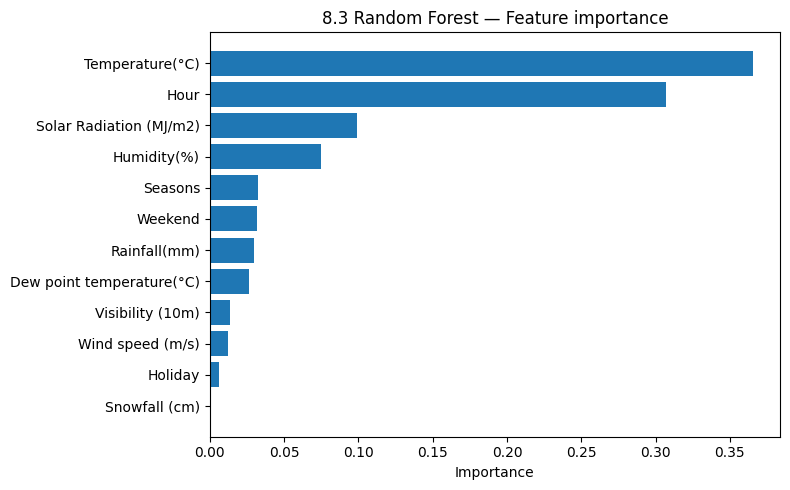

,feature,importance
1,Temperature(°C),0.365424
0,Hour,0.307308
6,Solar Radiation (MJ/m2),0.099066
2,Humidity(%),0.074853
9,Seasons,0.032341
11,Weekend,0.032037
7,Rainfall(mm),0.030074
5,Dew point temperature(°C),0.026214
4,Visibility (10m),0.013396
3,Wind speed (m/s),0.012532


In [45]:
imp = pd.DataFrame({'feature': X_train.columns,
					'importance': rf.feature_importances_}).sort_values('importance')

plt.figure(figsize=(8,5))
plt.barh(imp.feature, imp.importance)
plt.xlabel("Importance"); plt.title("8.3 Random Forest — Feature importance")
plt.tight_layout()
plt.savefig('fig_83_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()
display(imp.sort_values('importance', ascending=False))

Importance of each feature in both tree models, side by side.

In [46]:
imp_compare = pd.DataFrame({
    'Feature': X_train.columns,
    'Decision Tree': tree.feature_importances_,
    'Random Forest': rf.feature_importances_,
}).sort_values('Random Forest', ascending=False)

print(imp_compare.to_latex(escape=True, index=False, float_format="%.4f"))

\begin{tabular}{lrr}
\toprule
Feature & Decision Tree & Random Forest \\
\midrule
Temperature(°C) & 0.3629 & 0.3654 \\
Hour & 0.3335 & 0.3073 \\
Solar Radiation (MJ/m2) & 0.0953 & 0.0991 \\
Humidity(\%) & 0.0881 & 0.0749 \\
Seasons & 0.0358 & 0.0323 \\
Weekend & 0.0335 & 0.0320 \\
Rainfall(mm) & 0.0204 & 0.0301 \\
Dew point temperature(°C) & 0.0173 & 0.0262 \\
Visibility (10m) & 0.0046 & 0.0134 \\
Wind speed (m/s) & 0.0038 & 0.0125 \\
Holiday & 0.0040 & 0.0061 \\
Snowfall (cm) & 0.0007 & 0.0007 \\
\bottomrule
\end{tabular}



Comparison across every model for validation and test.

In [47]:
res = pd.DataFrame(results)
display(res.round(4))

test_only = res[res.Subset == "test"].set_index("Model")[["RMSE","MAE","R2"]].round(3)
display(test_only)

print("--- Full table (validation and test) ---")
print(res.set_index(["Model","Subset"]).round(4).to_latex(escape=True, float_format="%.4f"))

print("--- Test only ---")
print(test_only.to_latex(escape=True, float_format="%.3f"))

,Model,Subset,MSE,RMSE,MAE,R2
0,Baseline (mean),val,335166.7932,578.9359,464.5786,-0.0058
1,Baseline (mean),test,394653.6426,628.2146,490.5287,-0.0010
2,Linear Regression (OLS),val,196734.1977,443.5473,342.3645,0.4096
3,Linear Regression (OLS),test,234724.3776,484.4836,369.4715,0.4046
4,Decision Tree,val,88885.2143,298.1362,179.7246,0.7333
5,Decision Tree,test,67713.9596,260.2191,166.2874,0.8282
6,Random Forest,val,61805.4604,248.6070,153.8811,0.8145
7,Random Forest,test,41250.1054,203.1012,133.2425,0.8954


,RMSE,MAE,R2
Model,,,
Baseline (mean),628.215,490.529,-0.001
Linear Regression (OLS),484.484,369.472,0.405
Decision Tree,260.219,166.287,0.828
Random Forest,203.101,133.243,0.895


--- Full table (validation and test) ---
\begin{tabular}{llrrrr}
\toprule
 &  & MSE & RMSE & MAE & R2 \\
Model & Subset &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{Baseline (mean)} & val & 335166.7932 & 578.9359 & 464.5786 & -0.0058 \\
 & test & 394653.6426 & 628.2146 & 490.5287 & -0.0010 \\
\cline{1-6}
\multirow[t]{2}{*}{Linear Regression (OLS)} & val & 196734.1977 & 443.5473 & 342.3645 & 0.4096 \\
 & test & 234724.3776 & 484.4836 & 369.4715 & 0.4046 \\
\cline{1-6}
\multirow[t]{2}{*}{Decision Tree} & val & 88885.2143 & 298.1362 & 179.7246 & 0.7333 \\
 & test & 67713.9596 & 260.2191 & 166.2874 & 0.8282 \\
\cline{1-6}
\multirow[t]{2}{*}{Random Forest} & val & 61805.4604 & 248.6070 & 153.8811 & 0.8145 \\
 & test & 41250.1054 & 203.1012 & 133.2425 & 0.8954 \\
\cline{1-6}
\bottomrule
\end{tabular}

--- Test only ---
\begin{tabular}{lrrr}
\toprule
 & RMSE & MAE & R2 \\
Model &  &  &  \\
\midrule
Baseline (mean) & 628.215 & 490.529 & -0.001 \\
Linear Regression (OLS) & 484.484 & 369.472 & 0.4

Real versus predicted, linear against ensemble

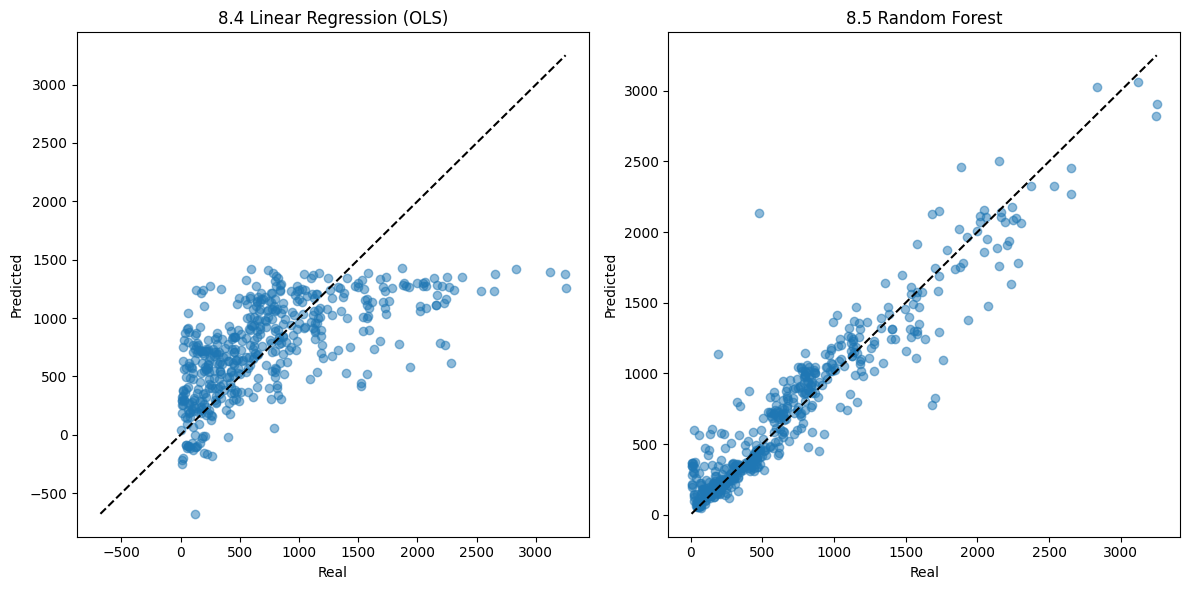

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

for ax, (pred, name) in zip(axes, [(ols_test, "8.4 Linear Regression (OLS)"), (rf_test, "8.5 Random Forest")]):
	ax.scatter(Y_test, pred, alpha=0.5)
	lims = [min(Y_test.min(), pred.min()), max(Y_test.max(), pred.max())]
	ax.plot(lims, lims, 'k--')
	ax.set_title(name); ax.set_xlabel("Real"); ax.set_ylabel("Predicted")

plt.tight_layout()
plt.savefig('fig_84_real_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()